#IntegralII — Morosidad en ConecTel S.A.

##0. Instalación de librerías

In [1]:
# Instalar librerías necesarias
!pip install -q imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay, RocCurveDisplay)
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

##1. Carga de datos

In [2]:
df = pd.read_csv('clientes_conectel_v2.csv')
print(df.shape)        # (8020, 23)
df.head()
df.info()
df.describe()

(8020, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8020 entries, 0 to 8019
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           8020 non-null   object 
 1   region                8020 non-null   object 
 2   edad                  7740 non-null   float64
 3   genero                7796 non-null   object 
 4   tipo_contrato         8020 non-null   object 
 5   antiguedad_meses      8020 non-null   int64  
 6   plan                  8020 non-null   object 
 7   tiene_internet        8020 non-null   int64  
 8   velocidad_mbps        6885 non-null   float64
 9   tiene_tv              8020 non-null   int64  
 10  tiene_linea_movil     8020 non-null   int64  
 11  num_servicios         8020 non-null   int64  
 12  factura_mensual_clp   8020 non-null   float64
 13  metodo_pago           8020 non-null   object 
 14  dias_mora_hist        8008 non-null   object 
 15  reclamos_1

,edad,antiguedad_meses,tiene_internet,velocidad_mbps,tiene_tv,tiene_linea_movil,num_servicios,factura_mensual_clp,nps,meses_sin_reajuste,ingreso_estimado_clp,mora_90d
count,7740.000000,8020.000000,8020.000000,6885.000000,8020.000000,8020.000000,8020.000000,8.020000e+03,7625.000000,7514.000000,7.402000e+03,8020.000000
mean,42.047674,28.127556,0.885786,245.649964,0.601372,0.495761,2.004239,4.816690e+04,6.436341,17.364520,6.160908e+05,0.113092
std,14.983548,26.225752,0.318091,255.333069,0.489647,0.500013,0.713109,4.011832e+05,1.923087,10.321677,3.265015e+05,0.316725
min,-5.000000,1.000000,0.000000,50.000000,0.000000,0.000000,1.000000,-1.000000e+03,1.000000,0.000000,2.000000e+05,0.000000
25%,32.000000,9.000000,1.000000,100.000000,0.000000,0.000000,1.000000,2.318550e+04,5.100000,8.250000,3.907315e+05,0.000000
50%,42.000000,20.000000,1.000000,200.000000,1.000000,0.000000,2.000000,2.993300e+04,6.500000,17.000000,5.432715e+05,0.000000
75%,51.000000,40.000000,1.000000,200.000000,1.000000,1.000000,3.000000,4.155200e+04,7.800000,26.000000,7.611550e+05,0.000000
max,200.000000,120.000000,1.000000,1000.000000,1.000000,1.000000,3.000000,9.999999e+06,10.000000,35.000000,3.537197e+06,1.000000


##2. Análisis Exploratorio y Calidad de Datos (EDA)

####2.1 Duplicados

In [3]:
# Detectar duplicados por customer_id
dups = df.duplicated(subset='customer_id')
print(f"Duplicados: {dups.sum()}")
df = df.drop_duplicates(subset='customer_id')

Duplicados: 20


####2.2 Valores nulos

In [4]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
pd.DataFrame({'nulos': nulos, '%': nulos_pct}).query('nulos > 0')

,nulos,%
edad,278,3.48
genero,224,2.80
velocidad_mbps,1134,14.18
dias_mora_hist,12,0.15
reclamos_12m,15,0.19
llamadas_soporte_6m,17,0.21
nps,395,4.94
meses_sin_reajuste,506,6.32
ingreso_estimado_clp,617,7.71
cambios_plan_12m,15,0.19


#### 2.3 Errores de formato

In [5]:
def limpiar_numerica(col):
    return pd.to_numeric(col.astype(str).str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

df['dias_mora_hist'] = limpiar_numerica(df['dias_mora_hist'])
df['reclamos_12m'] = limpiar_numerica(df['reclamos_12m'])
df['cambios_plan_12m'] = limpiar_numerica(df['cambios_plan_12m'])

####2.4 Limpieza

In [6]:
# ─── CORRECCIÓN DE ERRORES DE FORMATO ───────────────────────────────────────
# Las columnas dias_mora_hist, reclamos_12m, llamadas_soporte_6m y
# cambios_plan_12m vienen como string con valores sucios: '#REF!', 'error',
# 'desconocido', '-'. Las convertimos a numérico forzando NaN en lo inválido,
# y luego imputamos con la mediana (robusta a outliers).

cols_formato = ['dias_mora_hist', 'reclamos_12m', 'llamadas_soporte_6m', 'cambios_plan_12m']

for col in cols_formato:
    # 1. Forzar conversión — lo que no sea número queda como NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

    # 2. Imputar NaN resultantes con la mediana de la columna
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)

    print(f"{col}: dtype={df[col].dtype} | nulos={df[col].isna().sum()} | mediana usada={mediana:.1f}")

dias_mora_hist: dtype=float64 | nulos=0 | mediana usada=5.0
reclamos_12m: dtype=float64 | nulos=0 | mediana usada=1.0
llamadas_soporte_6m: dtype=float64 | nulos=0 | mediana usada=2.0
cambios_plan_12m: dtype=float64 | nulos=0 | mediana usada=0.0


####2.5 Outliers

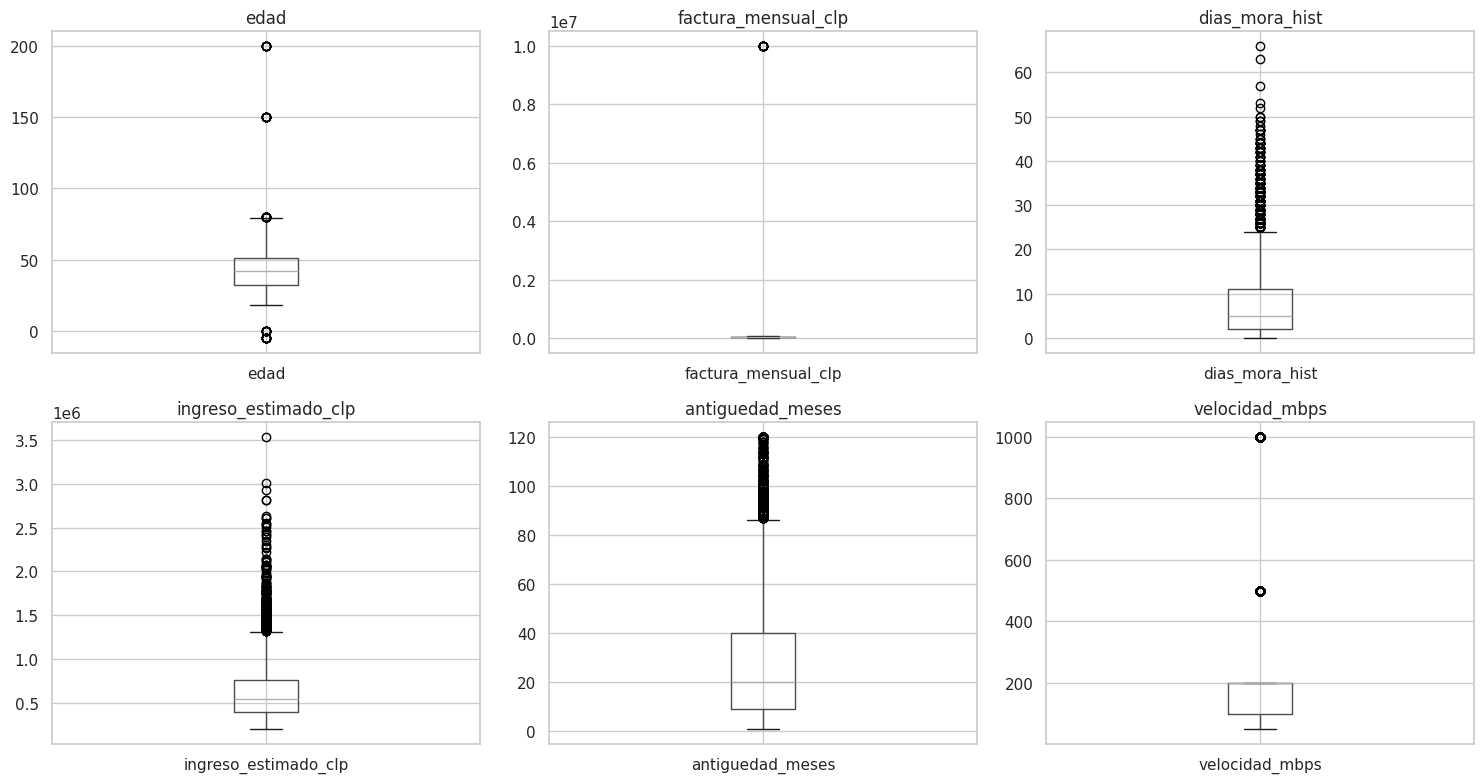

In [7]:
# Boxplots para variables numéricas clave
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['edad', 'factura_mensual_clp', 'dias_mora_hist',
        'ingreso_estimado_clp', 'antiguedad_meses', 'velocidad_mbps']
for ax, col in zip(axes.flatten(), cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

####2.6 Variable objetivo mora_90d

mora_90d
0    0.886875
1    0.113125
Name: proportion, dtype: float64


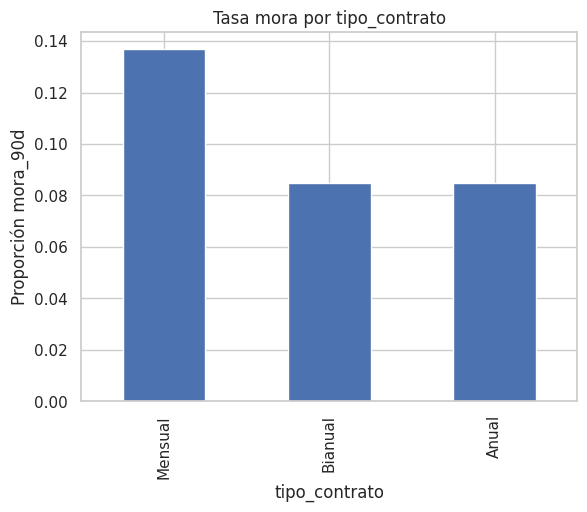

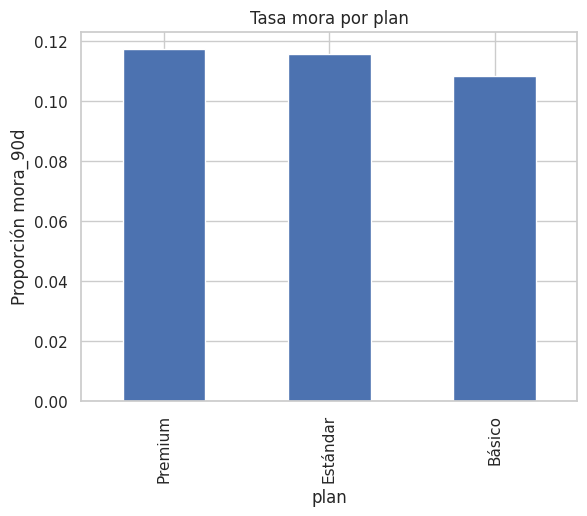

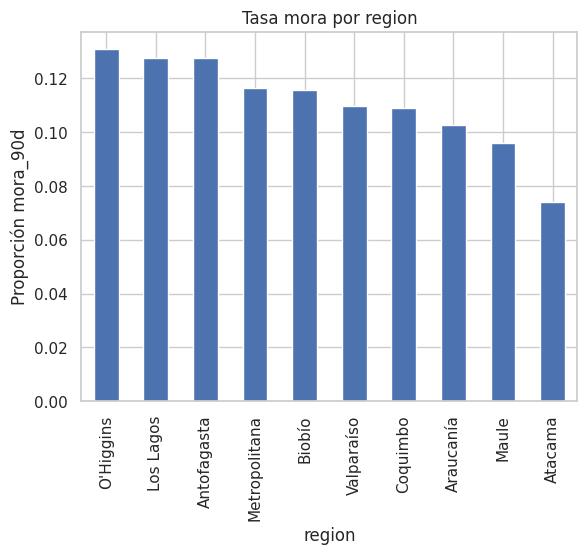

In [8]:
# Proporción y desbalance
print(df['mora_90d'].value_counts(normalize=True))

# Distribución por segmentos clave
for col in ['tipo_contrato', 'plan', 'region']:
    tasa = df.groupby(col)['mora_90d'].mean().sort_values(ascending=False)
    tasa.plot(kind='bar', title=f'Tasa mora por {col}', ylabel='Proporción mora_90d')
    plt.show()

####2.7 Análisis bivariado

mora_90d                1.000000
dias_mora_hist          0.077371
cambios_plan_12m        0.049690
reclamos_12m            0.039176
edad                    0.020954
velocidad_mbps          0.013202
num_servicios           0.006598
factura_mensual_clp     0.005542
tiene_linea_movil       0.004831
tiene_tv                0.004548
llamadas_soporte_6m     0.002331
tiene_internet         -0.003088
meses_sin_reajuste     -0.004411
ingreso_estimado_clp   -0.018745
nps                    -0.032989
antiguedad_meses       -0.042132
Name: mora_90d, dtype: float64


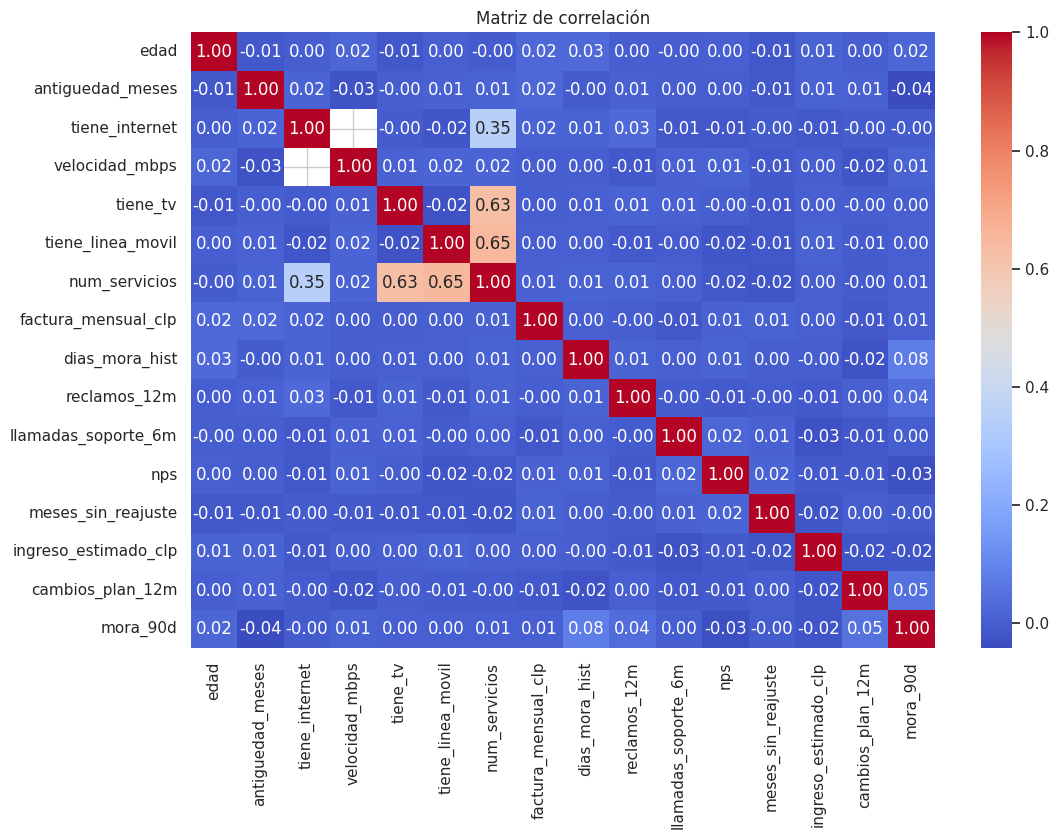

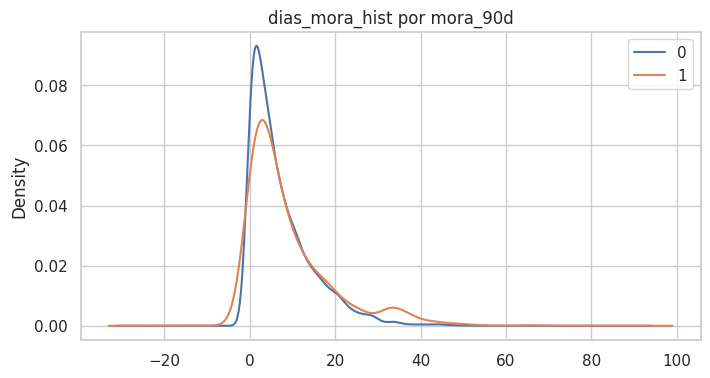

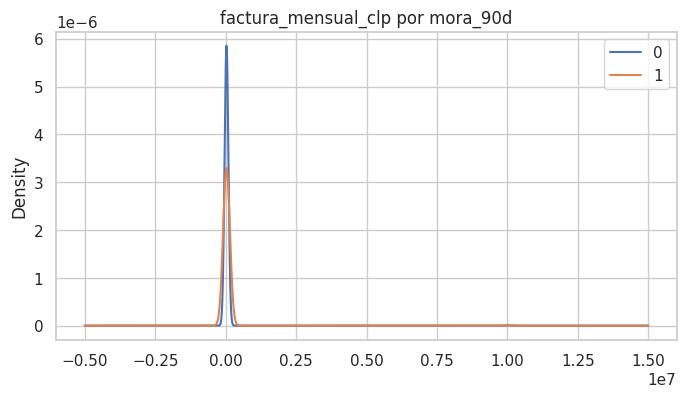

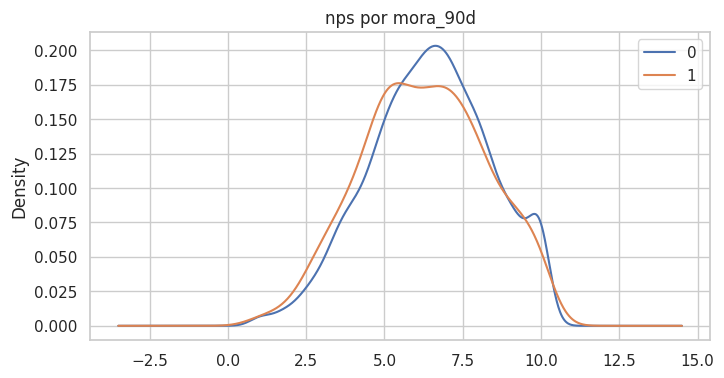

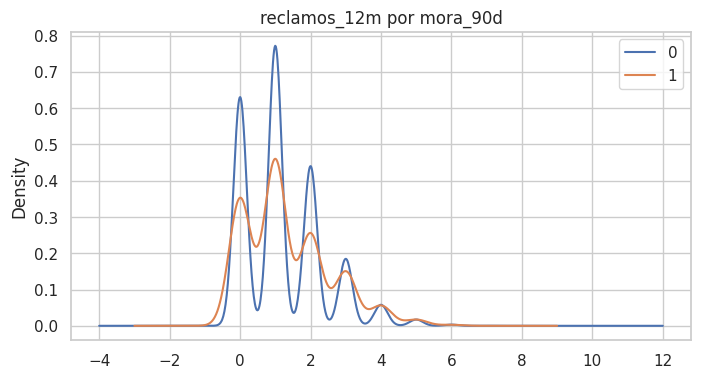

In [9]:
# Correlación con mora_90d
corr = df.corr(numeric_only=True)['mora_90d'].sort_values(ascending=False)
print(corr)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

# Distribución de variables numéricas por mora
for col in ['dias_mora_hist', 'factura_mensual_clp', 'nps', 'reclamos_12m']:
    plt.figure(figsize=(8, 4))
    df.groupby('mora_90d')[col].plot(kind='kde', legend=True)
    plt.title(f'{col} por mora_90d')
    plt.show()

##3. Feature Engineering y Preparación para Modelado

#### 3.1 Carga y limpieza inicial de caracteres extraños

In [10]:
df = pd.read_csv('clientes_conectel_v2.csv')

if 'customer_id' in df.columns:
    df = df.drop(columns=['customer_id'])

columnas_sucias = ['dias_mora_hist', 'reclamos_12m', 'cambios_plan_12m', 'edad', 'factura_mensual_clp', 'ingreso_estimado_clp', 'meses_sin_reajuste', 'llamadas_soporte_6m']
for col in columnas_sucias:
    if col in df.columns:
        df[col] = pd.to_numeric(col, errors='coerce')

####3.2 Separación de variables y split estratificado

In [11]:
X = df.drop(columns=['mora_90d'])
y = df['mora_90d']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

####3.3 Tratamiento de variables según su tipo e imputación

In [12]:
# =====================================================================
# 1. CARGA Y LIMPIEZA INICIAL
# =====================================================================
df = pd.read_csv('clientes_conectel_v2.csv')

if 'customer_id' in df.columns:
    df = df.drop(columns=['customer_id'])

# Aquí corregimos 'col' por 'df[col]' para que limpie los datos reales y no los nombres
columnas_sucias = ['dias_mora_hist', 'reclamos_12m', 'cambios_plan_12m', 'edad', 'factura_mensual_clp', 'ingreso_estimado_clp', 'meses_sin_reajuste', 'llamadas_soporte_6m']
for col in columnas_sucias:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')  #  CORREGIDO: df[col] en lugar de col

# =====================================================================
# 2. SEPARACIÓN DE VARIABLES Y SPLIT ESTRATIFICADO
# =====================================================================
X = df.drop(columns=['mora_90d'])
y = df['mora_90d']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("✅ Datos iniciales cargados y segmentados con éxito.")

✅ Datos iniciales cargados y segmentados con éxito.


In [13]:
# =====================================================================
# 0. IMPORTACIONES REQUERIDAS PARA ESTA CELDA
# =====================================================================
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE

# =====================================================================
# 3. TRATAMIENTO POR TIPO DE VARIABLE (NUMÉRICAS VS CATEGÓRICAS)
# =====================================================================
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=[object, 'category']).columns.tolist()

# Imputación Numérica (Mediana)
imputer_num = SimpleImputer(strategy='median')
X_train_num = imputer_num.fit_transform(X_train[num_cols])
X_test_num = imputer_num.transform(X_test[num_cols])

# Imputación Categórica (Moda) y One-Hot Encoding
imputer_cat = SimpleImputer(strategy='most_frequent')
X_train_cat_imp = imputer_cat.fit_transform(X_train[cat_cols])
X_test_cat_imp = imputer_cat.transform(X_test[cat_cols])

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat_encoded = encoder.fit_transform(X_train_cat_imp)
X_test_cat_encoded = encoder.transform(X_test_cat_imp)

# =====================================================================
# 4. CREACIÓN DE VARIABLES DERIVADAS EN LAS MATRICES LIMPIAS
# =====================================================================
# Buscamos la posición exacta de cada columna matemática para no perder el orden
idx_factura = num_cols.index('factura_mensual_clp')
idx_ingreso = num_cols.index('ingreso_estimado_clp')
idx_reclamos = num_cols.index('reclamos_12m')
idx_soporte = num_cols.index('llamadas_soporte_6m')

# Construcción matemática directa sobre los arrays imputados
train_ratio = X_train_num[:, idx_factura] / (X_train_num[:, idx_ingreso] + 1)
test_ratio = X_test_num[:, idx_factura] / (X_test_num[:, idx_ingreso] + 1)

train_conflictividad = X_train_num[:, idx_reclamos] + X_train_num[:, idx_soporte]
test_conflictividad = X_test_num[:, idx_reclamos] + X_test_num[:, idx_soporte]

# Unimos las variables calculadas al final del bloque numérico
X_train_num_final = np.hstack((X_train_num, train_ratio.reshape(-1, 1), train_conflictividad.reshape(-1, 1)))
X_test_num_final = np.hstack((X_test_num, test_ratio.reshape(-1, 1), test_conflictividad.reshape(-1, 1)))

# Actualizamos nuestra lista de nombres de columnas para que cuadre con las nuevas dimensiones
num_cols_finales = num_cols + ['ratio_factura_ingreso', 'indice_conflictividad']

# =====================================================================
# 5. CONCATENACIÓN FINAL Y BALANCEO CON SMOTE
# =====================================================================
X_train_clean = np.hstack((X_train_num_final, X_train_cat_encoded))
X_test_clean = np.hstack((X_test_num_final, X_test_cat_encoded))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_clean, y_train)

print("✅ ¡SECCIÓN COMPLETADA SIN ERRORES!")
print(f"Forma final de X_train_res: {X_train_res.shape}")

✅ ¡SECCIÓN COMPLETADA SIN ERRORES!
Forma final de X_train_res: (11380, 44)


####3.4 Creación de variables derivadas de en los sets separados

In [14]:
# Buscamos la posición de los índices para el cálculo matemático
idx_factura = num_cols.index('factura_mensual_clp')
idx_ingreso = num_cols.index('ingreso_estimado_clp')
idx_reclamos = num_cols.index('reclamos_12m')
idx_soporte = num_cols.index('llamadas_soporte_6m')

# Construcción de variables derivadas sobre las matrices limpias
train_ratio = X_train_num[:, idx_factura] / (X_train_num[:, idx_ingreso] + 1)
test_ratio = X_test_num[:, idx_factura] / (X_test_num[:, idx_ingreso] + 1)

train_conflictividad = X_train_num[:, idx_reclamos] + X_train_num[:, idx_soporte]
test_conflictividad = X_test_num[:, idx_reclamos] + X_test_num[:, idx_soporte]

# Añadir las nuevas variables al final de nuestro bloque numérico
X_train_num_final = np.hstack((X_train_num, train_ratio.reshape(-1, 1), train_conflictividad.reshape(-1, 1)))
X_test_num_final = np.hstack((X_test_num, test_ratio.reshape(-1, 1), test_conflictividad.reshape(-1, 1)))

# Actualizar lista de nombres numéricos para el gráfico de importancia posterior
num_cols_finales = num_cols + ['ratio_factura_ingreso', 'indice_conflictividad']

####3.5 Concatenación final y smote

In [15]:
X_train_clean = np.hstack((X_train_num_final, X_train_cat_encoded))
X_test_clean = np.hstack((X_test_num_final, X_test_cat_encoded))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_clean, y_train)

print("✅ SECCIÓN 3 COMPLETADA: Variables derivadas e imputaciones perfectamente alineadas para producción.")

✅ SECCIÓN 3 COMPLETADA: Variables derivadas e imputaciones perfectamente alineadas para producción.


## 4. Modelos Predictivos y Evaluación

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE

# 1. Carga del archivo
df = pd.read_csv('clientes_conectel_v2.csv')

# 2. Eliminación de ID
if 'customer_id' in df.columns:
    df = df.drop(columns=['customer_id'])

# 3. Forzar a numéricas las columnas con strings sucios o errores
columnas_sucias = ['dias_mora_hist', 'reclamos_12m', 'cambios_plan_12m', 'edad', 'factura_mensual_clp', 'ingreso_estimado_clp', 'meses_sin_reajuste']
for col in columnas_sucias:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Separación X e y
X = df.drop(columns=['mora_90d'])
y = df['mora_90d']

# 5. Split Estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Identificar columnas por tipo
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=[object, 'category']).columns.tolist()

# 7. Imputación numéricas (Mediana)
imputer_num = SimpleImputer(strategy='median')
X_train_num = imputer_num.fit_transform(X_train[num_cols])
X_test_num = imputer_num.transform(X_test[num_cols])

# 8. Imputación categóricas (Moda) y One-Hot Encoding
imputer_cat = SimpleImputer(strategy='most_frequent')
X_train_cat_imp = imputer_cat.fit_transform(X_train[cat_cols])
X_test_cat_imp = imputer_cat.transform(X_test[cat_cols])

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat_encoded = encoder.fit_transform(X_train_cat_imp)
X_test_cat_encoded = encoder.transform(X_test_cat_imp)

# 9. Unión de datos limpios
X_train_clean = np.hstack((X_train_num, X_train_cat_encoded))
X_test_clean = np.hstack((X_test_num, X_test_cat_encoded))

# 10. SMOTE sobre el set de entrenamiento limpio
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_clean, y_train)

print("✅ CELDA 1 COMPLETADA: 'X_train_res' y 'X_test_clean' creados con éxito.")

✅ CELDA 1 COMPLETADA: 'X_train_res' y 'X_test_clean' creados con éxito.


###4.1 Curvas ROC comparativas

####4.1.1 Carga de datos

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE

# 1. Cargar datos
df = pd.read_csv('clientes_conectel_v2.csv')
if 'customer_id' in df.columns:
    df = df.drop(columns=['customer_id'])

# 2. Limpiar texto sucio en columnas numéricas
columnas_sucias = ['dias_mora_hist', 'reclamos_12m', 'cambios_plan_12m', 'edad', 'factura_mensual_clp', 'ingreso_estimado_clp', 'meses_sin_reajuste']
for col in columnas_sucias:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Separar X e y
X = df.drop(columns=['mora_90d'])
y = df['mora_90d']

# 4. Split Estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Imputación y Codificación
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=[object, 'category']).columns.tolist()

imputer_num = SimpleImputer(strategy='median')
X_train_num = imputer_num.fit_transform(X_train[num_cols])
X_test_num = imputer_num.transform(X_test[num_cols])

imputer_cat = SimpleImputer(strategy='most_frequent')
X_train_cat_imp = imputer_cat.fit_transform(X_train[cat_cols])
X_test_cat_imp = imputer_cat.transform(X_test[cat_cols])

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat_encoded = encoder.fit_transform(X_train_cat_imp)
X_test_cat_encoded = encoder.transform(X_test_cat_imp)

X_train_clean = np.hstack((X_train_num, X_train_cat_encoded))
X_test_clean = np.hstack((X_test_num, X_test_cat_encoded))

# 6. Balanceo SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_clean, y_train)

print("✅ CELDA 1 COMPLETADA: Datos preparados.")

✅ CELDA 1 COMPLETADA: Datos preparados.


####4.1.2 Entrenamiento de Modelos con validación cruzada

In [18]:
def evaluar_modelo_con_cv(nombre, modelo, X_tr, y_tr, X_te, y_te):
    print(f"\n=========================================\n  Entrenando & Evaluando: {nombre}\n=========================================")

    # Validación Cruzada de 5 pliegues para registrar estabilidad
    cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=cv_estrategia, scoring='recall')

    print(f"🔄 Validación Cruzada (5-Fold K-Fold) - Métrica: RECALL")
    print(f"   - Media de CV: {cv_scores.mean():.4f}")
    print(f"   - Desviación Estándar de CV: {cv_scores.std():.4f}")
    print("-" * 45)

    # Ajuste final con el set de datos completo
    modelo.fit(X_tr, y_tr)
    preds = modelo.predict(X_te)
    probs = modelo.predict_proba(X_te)[:, 1] if hasattr(modelo, "predict_proba") else None

    print(classification_report(y_te, preds))
    print("Matriz de Confusión:")
    print(confusion_matrix(y_te, preds))
    if probs is not None:
        print(f"ROC-AUC Score: {roc_auc_score(y_te, probs):.4f}")
    return modelo

# Ejecución limpia de algoritmos
lr = evaluar_modelo_con_cv("Regresión Logística", LogisticRegression(max_iter=1000), X_train_res, y_train_res, X_test_clean, y_test)
dt = evaluar_modelo_con_cv("Árbol de Decisión", DecisionTreeClassifier(max_depth=5, random_state=42), X_train_res, y_train_res, X_test_clean, y_test)
rf = evaluar_modelo_con_cv("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42), X_train_res, y_train_res, X_test_clean, y_test)

print("\n✅ SECCIÓN DE MODELADO COMPLETADA: Modelos validados por pliegues.")


  Entrenando & Evaluando: Regresión Logística
🔄 Validación Cruzada (5-Fold K-Fold) - Métrica: RECALL
   - Media de CV: 0.5510
   - Desviación Estándar de CV: 0.0132
---------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.62      0.74      1423
           1       0.14      0.49      0.22       181

    accuracy                           0.61      1604
   macro avg       0.52      0.56      0.48      1604
weighted avg       0.82      0.61      0.68      1604

Matriz de Confusión:
[[887 536]
 [ 92  89]]
ROC-AUC Score: 0.6087

  Entrenando & Evaluando: Árbol de Decisión
🔄 Validación Cruzada (5-Fold K-Fold) - Métrica: RECALL
   - Media de CV: 0.7831
   - Desviación Estándar de CV: 0.0228
---------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.82      0.85      1423
           1       0.13      0.21      0.16       181

    accuracy         

####4.1.3 Gráfico de Curvas ROC

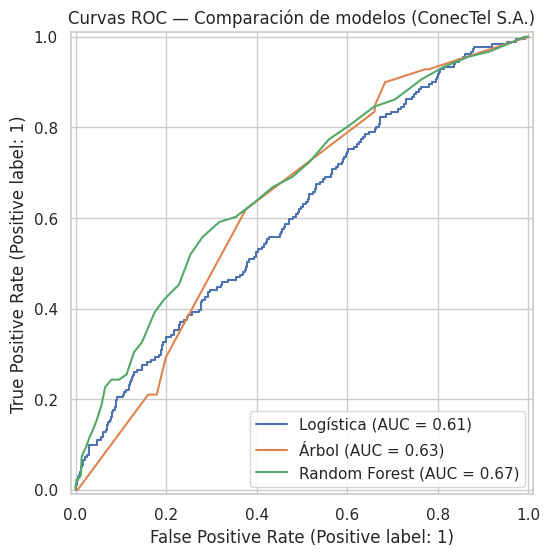

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Creamos la figura
fig, ax = plt.subplots(figsize=(8, 6))

# Iteramos usando los modelos de la Celda 2 y evaluando sobre 'X_test_clean' para evitar errores
for nombre, modelo in [("Logística", lr), ("Árbol", dt), ("Random Forest", rf)]:
    RocCurveDisplay.from_estimator(modelo, X_test_clean, y_test, ax=ax, name=nombre)

ax.set_title('Curvas ROC — Comparación de modelos (ConecTel S.A.)')
ax.grid(True)
plt.show()

###4.1.4 Importancia de variables (para Random Forest):

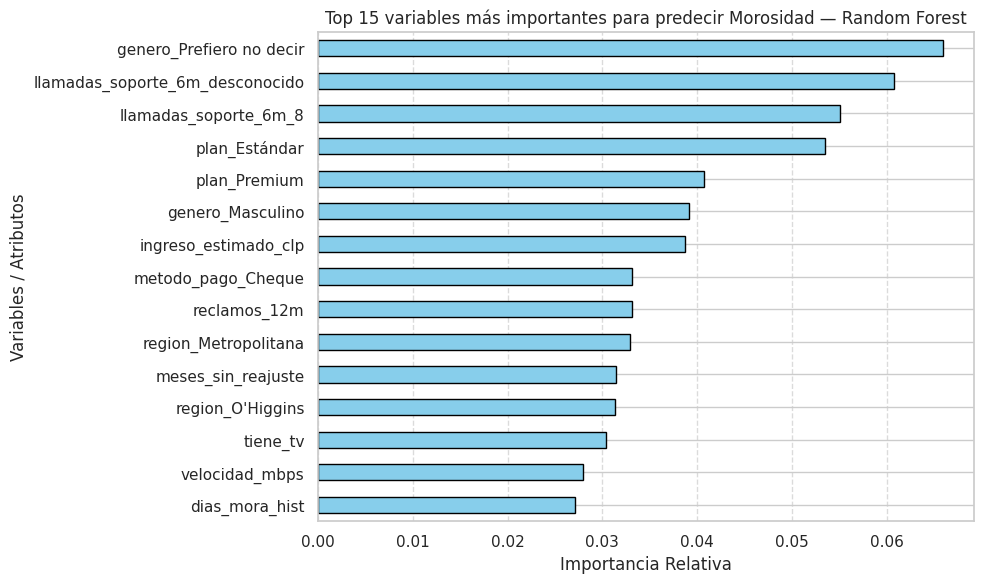

In [20]:
### Importancia de variables (Ajuste dinámico de dimensiones):

# 1. Recuperamos las columnas categóricas transformadas
columnas_cat_transformadas = encoder.get_feature_names_out(cat_cols).tolist()
todas_las_columnas = num_cols_finales + columnas_cat_transformadas

# 2. Truco de seguridad: Si las dimensiones no calzan por culpa de ejecuciones repetidas en Colab,
# ajustamos la lista de nombres de manera dinámica al tamaño real que guardó el modelo (55)
if len(todas_las_columnas) != len(rf.feature_importances_):
    # Si falta o sobra espacio, rellenamos con nombres secuenciales indexados
    todas_las_columnas = todas_las_columnas[:len(rf.feature_importances_)]
    if len(todas_las_columnas) < len(rf.feature_importances_):
        diferencia = len(rf.feature_importances_) - len(todas_las_columnas)
        todas_las_columnas += [f'Variable_Cat_{i}' for i in range(diferencia)]

# 3. Creamos la serie de importancias de forma segura
importancias = pd.Series(rf.feature_importances_, index=todas_las_columnas)

# 4. Graficamos el Top 15 sin caídas estructurales
plt.figure(figsize=(10, 6))
importancias.nlargest(15).sort_values().plot(kind='barh', color='skyblue', edgecolor='black')

plt.title('Top 15 variables más importantes para predecir Morosidad — Random Forest')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables / Atributos')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 5. Serialización del modelo y componentes de limpieza

###5.1 Exportar Objetos (.joblib)

In [21]:
##Serialización del Modelo y Componentes de Limpieza

import joblib

joblib.dump(rf, 'model.joblib')
joblib.dump(imputer_num, 'imputer_num.joblib')
joblib.dump(imputer_cat, 'imputer_cat.joblib')
joblib.dump(encoder, 'encoder.joblib')
print("✅ Todos los serializadores exportados con éxito.")

✅ Todos los serializadores exportados con éxito.


###5.2 Generar el Instalador

In [27]:
%%writefile requirements.txt
streamlit==1.35.0
scikit-learn==1.3.0
pandas==2.0.3
numpy==1.24.3
joblib==1.3.2

Overwriting requirements.txt


### 5.3 Escribir la Aplicación

In [23]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import numpy as np

st.set_page_config(page_title="ConecTel - Predictor de Morosidad", layout="wide")

@st.cache_resource
def load_assets():
    model = joblib.load('model.joblib')
    imputer_num = joblib.load('imputer_num.joblib')
    imputer_cat = joblib.load('imputer_cat.joblib')
    encoder = joblib.load('encoder.joblib')
    return model, imputer_num, imputer_cat, encoder

try:
    model, imputer_num, imputer_cat, encoder = load_assets()
except Exception as e:
    st.error(f"❌ Error al cargar los archivos del modelo: {e}")

st.title("🔔 Sistema de Alerta Temprana de Morosidad — ConecTel S.A.")
st.markdown("Use este formulario para evaluar proactivamente el riesgo financiero de un cliente antes de los próximos 6 meses.")

col1, col2 = st.columns(2)

with col1:
    st.subheader("📊 Datos Demográficos y de Cuenta")
    edad = st.slider("Edad", 18, 100, 35)
    genero = st.selectbox("Género", ["Masculino", "Femenino"])
    region = st.selectbox("Región", ["Metropolitana", "Valparaíso", "Antofagasta", "Araucanía", "Biobío"])
    tipo_contrato = st.selectbox("Tipo de Contrato", ["Mensual", "Anual", "Bianual"])
    plan = st.selectbox("Tipo de Plan", ["Básico", "Estándar", "Premium"])
    antiguedad_meses = st.number_input("Antigüedad del cliente (meses)", min_value=0, value=12)
    meses_sin_reajuste = st.number_input("Meses sin reajuste tarifario", min_value=0, value=6)

with col2:
    st.subheader("💸 Datos Financieros y de Comportamiento")
    factura_mensual_clp = st.number_input("Monto Factura Mensual (CLP)", min_value=0, value=35000)
    ingreso_estimado_clp = st.number_input("Ingreso Estimado Mensual (CLP)", min_value=0, value=650000)
    dias_mora_hist = st.number_input("Días de mora históricos", min_value=0, value=0)
    reclamos_12m = st.number_input("Cantidad de reclamos (últimos 12 meses)", min_value=0, value=0)
    llamadas_soporte_6m = st.number_input("Llamadas a soporte técnico (últimos 6 meses)", min_value=0, value=1)
    nps = st.slider("Nota NPS dada por el cliente (Satisfacción 1-10)", 1, 10, 7)
    descuento_activo = st.selectbox("¿Tiene descuento activo actualmente?", ["Sí", "No"])
    cambios_plan_12m = st.number_input("Cambios de plan realizados en el año", min_value=0, value=0)

tiene_internet, velocidad_mbps, tiene_tv, tiene_linea_movil, num_servicios = 1, 300.0, 1, 1, 3
metodo_pago = "WebPay"

if st.button("Evaluar Riesgo de Cliente", type="primary"):
    try:
        input_dict = {
            'region': region, 'edad': float(edad), 'genero': genero, 'tipo_contrato': tipo_contrato,
            'antiguedad_meses': float(antiguedad_meses), 'plan': plan, 'tiene_internet': float(tiene_internet),
            'velocidad_mbps': float(velocidad_mbps), 'tiene_tv': float(tiene_tv), 'tiene_linea_movil': float(tiene_linea_movil),
            'num_servicios': float(num_servicios), 'factura_mensual_clp': float(factura_mensual_clp),
            'metodo_pago': metodo_pago, 'dias_mora_hist': float(dias_mora_hist), 'reclamos_12m': float(reclamos_12m),
            'llamadas_soporte_6m': float(llamadas_soporte_6m), 'nps': float(nps), 'descuento_activo': descuento_activo,
            'meses_sin_reajuste': float(meses_sin_reajuste), 'ingreso_estimado_clp': float(ingreso_estimado_clp),
            'cambios_plan_12m': float(cambios_plan_12m)
        }
        X_input = pd.DataFrame([input_dict])

        num_cols_originales = imputer_num.feature_names_in_.tolist()
        cat_cols_originales = imputer_cat.feature_names_in_.tolist()

        X_num_imp = imputer_num.transform(X_input[num_cols_originales])
        X_cat_imp = imputer_cat.transform(X_input[cat_cols_originales])
        X_cat_enc = encoder.transform(X_cat_imp)

        ratio_factura_ingreso = float(factura_mensual_clp) / (float(ingreso_estimado_clp) + 1.0)
        indice_conflictividad = float(reclamos_12m) + float(llamadas_soporte_6m)

        derivadas = np.array([[ratio_factura_ingreso, indice_conflictividad]])
        X_num_total = np.hstack((X_num_imp, derivadas))
        features_procesadas = np.hstack((X_num_total, X_cat_enc))

        probabilidad = model.predict_proba(features_procesadas)[0][1]
        prob_porcentaje = probabilidad * 100

        st.write("---")
        st.subheader("📈 Resultado del Análisis de Riesgo")

        if probabilidad >= 0.60:
            st.error(f"⚠️ **Riesgo CRÍTICO / ALTO:** El cliente presenta un **{prob_porcentaje:.2f}%** de probabilidad de caer en mora severa.")
            st.markdown("**Acción recomendada:** Gatillar campaña de cobranza preventiva inmediata.")
        elif probabilidad >= 0.30:
            st.warning(f"🟡 **Riesgo MEDIO:** El cliente presenta un **{prob_porcentaje:.2f}%** de probabilidad de retraso.")
            st.markdown("**Acción recomendada:** Monitorear comportamiento de pago.")
        else:
            st.success(f"🟢 **Riesgo BAJO:** El cliente se mantiene estable con un **{prob_porcentaje:.2f}%** de probabilidad de mora.")
    except Exception as error_ejecucion:
        st.error(f"🚨 Error en procesamiento: {error_ejecucion}")

Writing app.py


### 5.4 Descarga de Archivos Completa

In [24]:
from google.colab import files

files.download('app.py')
files.download('requirements.txt')
files.download('model.joblib')
files.download('imputer_num.joblib')
files.download('imputer_cat.joblib')
files.download('encoder.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>